# Analysis of relation between Guardian coverage of geopolitical crises and commodity price action

# Contents

*Stuff to add*

- Contents structure
- Explain what the project is about
- How we carried out the analysis
- What are the tools used
- gitignore api key

# 1. Introduction

Online media coverage of geopolitical crises is a major source of readily available information for traders globally. So commodity price action should be influenced by investor sentiment surrounding these published articles.

We know that the media shapes narratives around these markets which affects investor sentiment. Understanding how a major news outlet like the Guardian covers commonly traded commodities offers insight into the information environment that shapes public perception and potentially market behaviour. The Guardian is generally seen as a reliable and unbiased centre-left leaning news publisher, and we assume here that the publications released are factual and have no intention of steering the price of commodities any certain way. We are just aiming to see how their publications affect the markets.

# 1.1 Research questions
1. How does the volume and frequency of Guardian commodity coverage change around major geopolitical events (e.g. Iran war, Russia - Ukraine war, OPEC production decisions, COVID supply disruptions)?

2. Which commodities out of oil, gas, wheat and gold receive disproportionate media attention relative to others, and has this composition shifted over time?

3. Is there a measurable time delay between spikes in Guardian commodity coverage and movements in commodity prices?

# 2. Data Acquisition
- Our data range is from 1/1/2020 to 31/3/2026

Our primary data source is the Guardian API, using commodity-related search terms we collected date, section, title and body text
- We searched keywords such as brent oil, gold, natural gas, wheat, OPEC and energy crisis
- We scoured 20 articles in intervals of every week
- The keywords OPEC and energy crisis are most commonly associated with commodities and geopolitical tensions, since most of these wars are fought over oil which heavily affects energy prices globally.

Our secondary data source is commodity price data is sourced from yahoo finance, using the python package yfinance.
- Here we collected price and date on a weekly basis

In [21]:
import json
import requests
import pandas as pd
import time

# Load API key from keys.json
with open('keys.json') as f:
    key = json.load(f)

API_KEY = key['guardian']['api_key']
BASE_URL = 'https://content.guardianapis.com'

# Generate (Monday, Sunday) pairs for each week from Jan 2020 to Mar 2026
week_starts = pd.date_range("2020-01-01", "2026-03-31", freq="W-MON") # W-Mon: Weekly starting on Monday
date_ranges = []
for d in week_starts:
    start = d.strftime("%Y-%m-%d")  # parse the string as a date
    end = (d + pd.Timedelta(days=6)).strftime("%Y-%m-%d") # pd.Timedelta: adds 6 days to the date, so it starts on next week.
    date_ranges.append((start, end))

print(f"Total weeks to collect: {len(date_ranges)}")

all_results = []

for from_date, to_date in date_ranges:
    parameters = {
        "api-key": API_KEY,
        "q": "oil OR natural gas OR gold OR OPEC OR energy crisis",
        "page-size": 20,   # fetch 20 articles per week
        "page": 1,
        "show-fields": "bodyText",
        "from-date": from_date,
        "to-date": to_date,
        "order-by": "relevance"
    }

    try:
        response = requests.get(f"{BASE_URL}/search", params=parameters)
        response.raise_for_status()
        data = response.json()['response']
    except Exception as e:
        print(f"  Error on {from_date}: {e}")
        continue

    for article in data['results']:
        all_results.append({
            'date': article.get('webPublicationDate'),
            'section': article.get('sectionName'),
            'title': article.get('webTitle'),
            'body': article.get('fields', {}).get('bodyText', '')
        })

    time.sleep(0.25)

print(f"Collection complete: {len(all_results)} articles collected")

df = pd.DataFrame(all_results)
df['date'] = pd.to_datetime(df['date'], utc=True)
df = df.drop_duplicates(subset=['title']).reset_index(drop=True)
df.to_csv('data/guardian_commodities.csv', index=False)
print(f"Done. {len(df)} articles saved to data/guardian_commodities.csv")

Total weeks to collect: 326
Collection complete: 6520 articles collected
Done. 6514 articles saved to data/guardian_commodities.csv


In [24]:
import yfinance as yf


# Define commodity tickers
# Yahoo Finance uses these symbols for common commodities futures:
commodities = {
    "Gold":        "GC=F",    
    "Brent Oil":   "BZ=F",   # brent crude
    "Natural Gas": "NG=F",   
}

# Download historical data
data = yf.download(
    tickers=list(commodities.values()),
    start="2020-01-01",
    end="2026-03-31",
    interval="1wk"       # 1w; weekly
)

# Extract closing prices only
close_prices = data["Close"]
close_prices.columns = list(commodities.keys())

df_commodities_prices = pd.DataFrame(close_prices)


print(close_prices.head())


[*********************100%***********************]  3 of 3 completed

                 Gold    Brent Oil  Natural Gas
Date                                           
2020-01-01  68.269997  1571.800049        2.162
2020-01-08  64.489998  1542.400024        2.187
2020-01-15  64.589996  1556.400024        1.895
2020-01-22  59.509998  1569.199951        1.934
2020-01-29  53.959999  1550.400024        1.872


# IDA

,date,section,title,body
0,2020-01-08 09:00:23+00:00,Business,Why Iran crisis is unlikely to hit US consumer...,For many older Americans the thought of war in...
1,2020-01-12 10:00:32+00:00,Art and design,"‘Art into nature, nature into art’: César Manr...",A sea of gnarled black lava spills in through ...
2,2020-01-09 05:30:01+00:00,Culture,Country diary: the natural and supernatural co...,"People stopped. They got out of their cars, st..."


,date,section,title,body
6511,2026-03-31 16:00:59+00:00,Sport,A gleaming tribute to Mary Rand’s gold | Brief...,"As a schoolboy, I was fascinated by coverage o..."
6512,2026-03-30 06:22:03+00:00,Australia news,Labor backs Greens inquiry into gas export tax...,That’s all for the blog today. Here is a recap...
6513,2026-04-01 14:00:01+00:00,Business,Would more North Sea drilling mean lower energ...,Oil prices hit $100 a barrel soon after the US...


,date,section,title,body
124,2020-02-17 16:23:18+00:00,UK news,"UK must prepare for more intense storms, clima...",Britain must brace for more storms like Dennis...
1376,2021-04-28 04:00:23+00:00,World news,‘People phone up pleading’: the volunteers bat...,For more than two weeks the calls have kept on...
6147,2025-11-27 15:29:00+00:00,Football,Football Daily | Liverpool’s crisis analysis b...,THE ECHO CHAMBER When Liverpool players are pu...


Shape of dataframe (rows, columns): (6514, 4)
-------------------------------------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6514 entries, 0 to 6513
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype              
---  ------   --------------  -----              
 0   date     6514 non-null   datetime64[ns, UTC]
 1   section  6514 non-null   object             
 2   title    6514 non-null   object             
 3   body     6514 non-null   object             
dtypes: datetime64[ns, UTC](1), object(3)
memory usage: 203.7+ KB
-------------------------------------------------------------------------------------------
Missing values per column:
date       0
section    0
title      0
body       0
dtype: int64
-------------------------------------------------------------------------------------------
Number of fully duplicated rows: 0
Number of duplicate titles: 0
Number of duplicate body text: 16
---------------

,date,section,title,body
count,6514,6514,6514,6514
unique,NaN,45,6514,6498
top,NaN,Business,Why Iran crisis is unlikely to hit US consumer...,
freq,NaN,1389,1,17
mean,2023-02-19 04:44:22.584126464+00:00,NaN,NaN,NaN
min,2020-01-06 17:10:25+00:00,NaN,NaN,NaN
25%,2021-07-28 12:18:07+00:00,NaN,NaN,NaN
50%,2023-02-18 10:28:06.500000+00:00,NaN,NaN,NaN
75%,2024-09-12 09:45:19.500000+00:00,NaN,NaN,NaN
max,2026-04-05 18:22:38+00:00,NaN,NaN,NaN


-------------------------------------------------------------------------------------------
Article counts by section:
section
Business          1389
Environment       1128
World news         729
Australia news     509
Sport              393
US news            385
Opinion            285
Money              276
Politics           178
UK news            133
Name: count, dtype: int64
-------------------------------------------------------------------------------------------
Earliest article: 2020-01-06 17:10:25+00:00
Latest article:   2026-04-05 18:22:38+00:00
-------------------------------------------------------------------------------------------
Word count summary:
count     6514.000000
mean      1013.455481
std       1344.967542
min          0.000000
25%        537.000000
50%        719.000000
75%        970.000000
max      23984.000000
Name: word_count, dtype: float64
Articles under 50 words (likely stubs): 20


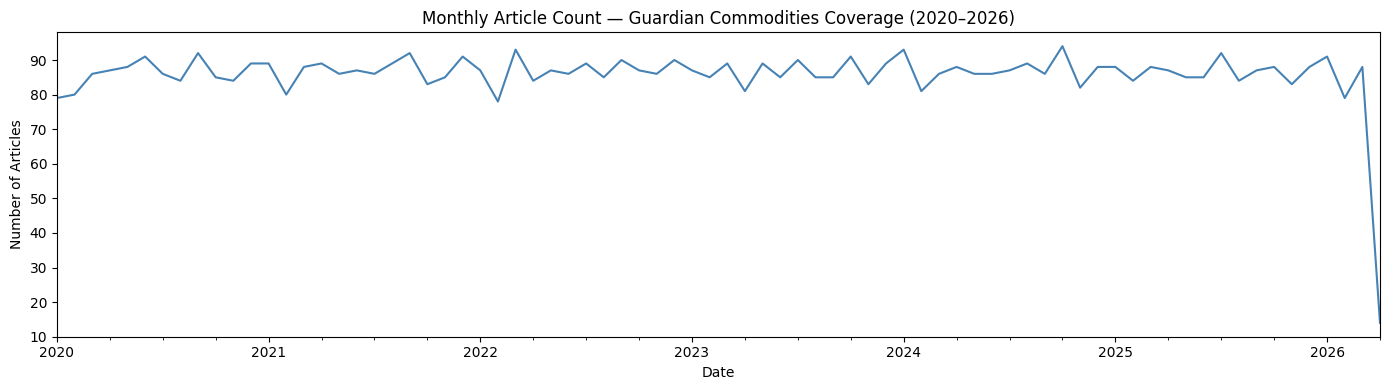

,Gold,Brent Oil,Natural Gas
Date,,,
2020-01-01,68.269997,1571.800049,2.162
2020-01-08,64.489998,1542.400024,2.187
2020-01-15,64.589996,1556.400024,1.895


,Gold,Brent Oil,Natural Gas
Date,,,
2026-03-11,103.419998,5001.000000,3.033
2026-03-18,104.489998,4399.299805,2.943
2026-03-25,118.349998,4647.600098,2.884


,Gold,Brent Oil,Natural Gas
Date,,,
2025-03-05,69.559998,2912.899902,4.453
2020-04-08,29.600000,1756.699951,1.650
2025-09-24,67.019997,3840.800049,3.303


-------------------------------------------------------------------------------------------
Shape: (326, 3)
Data types:
Gold           float64
Brent Oil      float64
Natural Gas    float64
dtype: object
-------------------------------------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 326 entries, 2020-01-01 to 2026-03-25
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Gold         326 non-null    float64
 1   Brent Oil    326 non-null    float64
 2   Natural Gas  326 non-null    float64
dtypes: float64(3)
memory usage: 10.2 KB
-------------------------------------------------------------------------------------------
Missing values per commodity:
Gold           0
Brent Oil      0
Natural Gas    0
dtype: int64
-------------------------------------------------------------------------------------------
Any duplicate rows? 0
-------------------------------

,Gold,Brent Oil,Natural Gas
count,326.000000,326.000000,326.000000
mean,74.009785,2300.191409,3.506696
std,18.785563,821.975852,1.666411
min,19.330000,1524.900024,1.575000
25%,65.212503,1804.475006,2.438750
50%,74.860001,1927.349976,2.984500
75%,84.705002,2515.075012,3.984000
max,127.980003,5229.700195,9.329000


-------------------------------------------------------------------------------------------
Earliest date: 2020-01-01 00:00:00
Latest date:   2026-03-25 00:00:00
-------------------------------------------------------------------------------------------
Zero or negative price counts:


In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

splitter = "-------------------------------------------------------------------------------------------"

#displays first 3, last 3, and 3 random rows of the dataframe to check the data looks like how it is expected to.
display(df.head(3))
display(df.tail(3))
display(df.sample(3))

#displays the shape of the dataframe
print("Shape of dataframe (rows, columns):", df.shape)

#summarises dataframe structure: row count, non-null counts, and data types per column
print(splitter)
df.info()

#check the number of missing values per column 
print(splitter)
print("Missing values per column:")
print(df.isna().sum())

#Check for duplicated rows, titles, or body text.
print(splitter)
print("Number of fully duplicated rows:", df.duplicated().sum())
print("Number of duplicate titles:", df.duplicated(subset=['title']).sum())
print("Number of duplicate body text:", df.duplicated(subset=['body']).sum())

#shows summary stats for all columns
print(splitter)
print("Descriptive statistics — Guardian articles:")
display(df.describe(include='all'))

#shows the count of articles by section(only the top 10 sections are shown))
print(splitter)
print("Article counts by section:")
print(df['section'].value_counts().head(10))

#confirms the actual date range of the data
print(splitter)
print(f"Earliest article: {df['date'].min()}")
print(f"Latest article:   {df['date'].max()}")

#Checks word count distribution
print(splitter)
df['word_count'] = df['body'].str.split().str.len()
print("Word count summary:")
print(df['word_count'].describe())
print(f"Articles under 50 words (likely stubs): {(df['word_count'] < 50).sum()}")


#plots article counts over time to spot unexpected gaps in coverage
monthly_counts = df.set_index('date').resample('ME').size()
fig, ax = plt.subplots(figsize=(14, 4))
monthly_counts.plot(ax=ax, color='steelblue')
ax.set_title('Monthly Article Count — Guardian Commodities Coverage (2020–2026)')
ax.set_ylabel('Number of Articles')
ax.set_xlabel('Date')
plt.tight_layout()
plt.show()


#--------------------------------------------------------------------------------------
#Now we do the same for the commodities prices data
display(df_commodities_prices.head(3))
display(df_commodities_prices.tail(3))
display(df_commodities_prices.sample(3))

print(splitter)
print("Shape:", df_commodities_prices.shape)
print("Data types:")
print(df_commodities_prices.dtypes)

print(splitter)
df_commodities_prices.info()

print(splitter)
print("Missing values per commodity:")
print(df_commodities_prices.isna().sum())

print(splitter)
print("Any duplicate rows?", df_commodities_prices.duplicated().sum())

print(splitter)
print("Descriptive statistics — commodity prices:")
display(df_commodities_prices.describe())

print(splitter)
print(f"Earliest date: {df_commodities_prices.index.min()}")
print(f"Latest date:   {df_commodities_prices.index.max()}")

#Checks for zero or negative prices, which are likely errors in commodity price data
print("-------------------------------------------------------------------------------------------")
print("Zero or negative price counts:")
for col in df_commodities_prices.columns:
    n = (df_commodities_prices[col] <= 0).sum()
    if n > 0:
        print(f"  {col}: {n} rows")


# Data wrangling

# EDA  

# Visualisation